# Brain Tumor MRI Classification - Exploratory Data Analysis (EDA)

In [1]:
# ==========================================
# Standard Library
# ==========================================
from pathlib import Path
import os
import random
import warnings

# ==========================================
# Data Handling
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# Image Processing
# ==========================================
import cv2

# ==========================================
# Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# TensorFlow
# ==========================================
import tensorflow as tf

# ==========================================
# Notebook Configuration
# ==========================================
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("=" * 60)
print("All libraries imported successfully.")
print(f"TensorFlow Version : {tf.__version__}")
print(f"OpenCV Version     : {cv2.__version__}")
print(f"NumPy Version      : {np.__version__}")
print(f"Pandas Version     : {pd.__version__}")
print("=" * 60)

All libraries imported successfully.
TensorFlow Version : 2.21.0
OpenCV Version     : 4.13.0
NumPy Version      : 2.4.6
Pandas Version     : 3.0.4


In [2]:
# ==========================================
# Project Configuration
# ==========================================

# Project Root Directory
PROJECT_ROOT = Path.cwd().parent

# Dataset Paths
DATA_DIR = PROJECT_ROOT / "data"

TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

# Model Directory
MODEL_DIR = PROJECT_ROOT / "models"

# Report Directory
REPORT_DIR = PROJECT_ROOT / "reports"

# Image Directory
IMAGE_DIR = PROJECT_ROOT / "images"

# Image Parameters
IMAGE_SIZE = (224, 224)
IMAGE_HEIGHT = IMAGE_SIZE[0]
IMAGE_WIDTH = IMAGE_SIZE[1]
IMAGE_CHANNELS = 3

# Training Parameters (Used Later)
BATCH_SIZE = 32
RANDOM_STATE = 42

print("=" * 60)
print("Project Configuration Loaded Successfully")
print("=" * 60)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Training Path: {TRAIN_DIR}")
print(f"Testing Path : {TEST_DIR}")
print(f"Models Path  : {MODEL_DIR}")
print(f"Reports Path : {REPORT_DIR}")
print(f"Images Path  : {IMAGE_DIR}")

print("=" * 60)
print(f"Image Size   : {IMAGE_SIZE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Random Seed  : {RANDOM_STATE}")
print("=" * 60)

Project Configuration Loaded Successfully
Project Root : c:\Users\SAINATH\github projects\brain-tumor-detector
Training Path: c:\Users\SAINATH\github projects\brain-tumor-detector\data\Training
Testing Path : c:\Users\SAINATH\github projects\brain-tumor-detector\data\Testing
Models Path  : c:\Users\SAINATH\github projects\brain-tumor-detector\models
Reports Path : c:\Users\SAINATH\github projects\brain-tumor-detector\reports
Images Path  : c:\Users\SAINATH\github projects\brain-tumor-detector\images
Image Size   : (224, 224)
Batch Size   : 32
Random Seed  : 42


In [3]:
# ==========================================
# Set Random Seed
# ==========================================

# Python Random
random.seed(RANDOM_STATE)

# NumPy Random
np.random.seed(RANDOM_STATE)

# TensorFlow Random
tf.random.set_seed(RANDOM_STATE)

print("=" * 60)
print("Random seed has been set successfully.")
print(f"Random Seed : {RANDOM_STATE}")
print("=" * 60)

Random seed has been set successfully.
Random Seed : 42


# Dataset Validation

In [4]:
# ==========================================
# Validate Dataset Structure
# ==========================================

required_classes = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

print("=" * 60)
print("Checking Dataset Structure...")
print("=" * 60)

# Check Training Folder
if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"Training folder not found:\n{TRAIN_DIR}")

# Check Testing Folder
if not TEST_DIR.exists():
    raise FileNotFoundError(f"Testing folder not found:\n{TEST_DIR}")

print("Training and Testing folders found.\n")

# Verify Class Folders
for class_name in required_classes:

    train_class_path = TRAIN_DIR / class_name
    test_class_path = TEST_DIR / class_name

    if not train_class_path.exists():
        raise FileNotFoundError(f"Missing training class folder: {class_name}")

    if not test_class_path.exists():
        raise FileNotFoundError(f"Missing testing class folder: {class_name}")

    print(f"{class_name:<12} ✓")

print("\nDataset structure is valid.")
print("=" * 60)

Checking Dataset Structure...
Training and Testing folders found.

glioma       ✓
meningioma   ✓
pituitary    ✓
notumor      ✓

Dataset structure is valid.


# Discover Class Names

In [5]:

CLASS_NAMES = sorted(
    [
        folder.name
        for folder in TRAIN_DIR.iterdir()
        if folder.is_dir()
    ]
)

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("Classes Found")
print("=" * 60)

for idx, class_name in enumerate(CLASS_NAMES):
    print(f"{idx} --> {class_name}")

print("=" * 60)
print(f"Total Classes : {NUM_CLASSES}")
print("=" * 60)

Classes Found
0 --> glioma
1 --> meningioma
2 --> notumor
3 --> pituitary
Total Classes : 4


In [6]:
# ==========================================
# Count Images
# ==========================================

train_counts = {}
test_counts = {}

for class_name in CLASS_NAMES:

    train_counts[class_name] = len(
        list((TRAIN_DIR / class_name).glob("*"))
    )

    test_counts[class_name] = len(
        list((TEST_DIR / class_name).glob("*"))
    )

dataset_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Training Images": [train_counts[c] for c in CLASS_NAMES],
    "Testing Images": [test_counts[c] for c in CLASS_NAMES]
})

dataset_df["Total Images"] = (
    dataset_df["Training Images"] +
    dataset_df["Testing Images"]
)

dataset_df

,Class,Training Images,Testing Images,Total Images
0,glioma,1400,400,1800
1,meningioma,1400,400,1800
2,notumor,1400,400,1800
3,pituitary,1400,400,1800


Dataset Summary

In [7]:
total_train = dataset_df["Training Images"].sum()
total_test = dataset_df["Testing Images"].sum()
total_images = dataset_df["Total Images"].sum()

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

print(f"Number of Classes     : {NUM_CLASSES}")
print(f"Training Images       : {total_train}")
print(f"Testing Images        : {total_test}")
print(f"Total Images          : {total_images}")

print("=" * 60)

Dataset Summary
Number of Classes     : 4
Training Images       : 5600
Testing Images        : 1600
Total Images          : 7200


Class Distribution

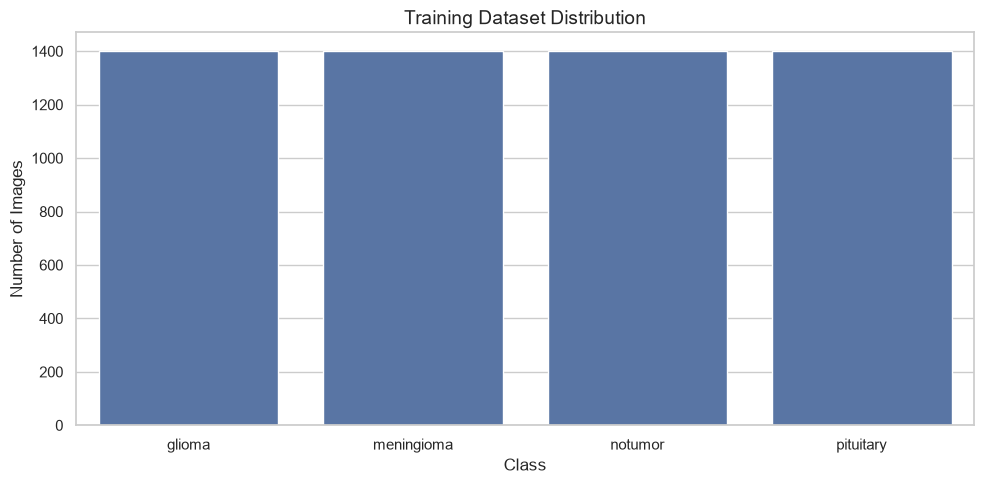

In [8]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=dataset_df,
    x="Class",
    y="Training Images"
)

plt.title("Training Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

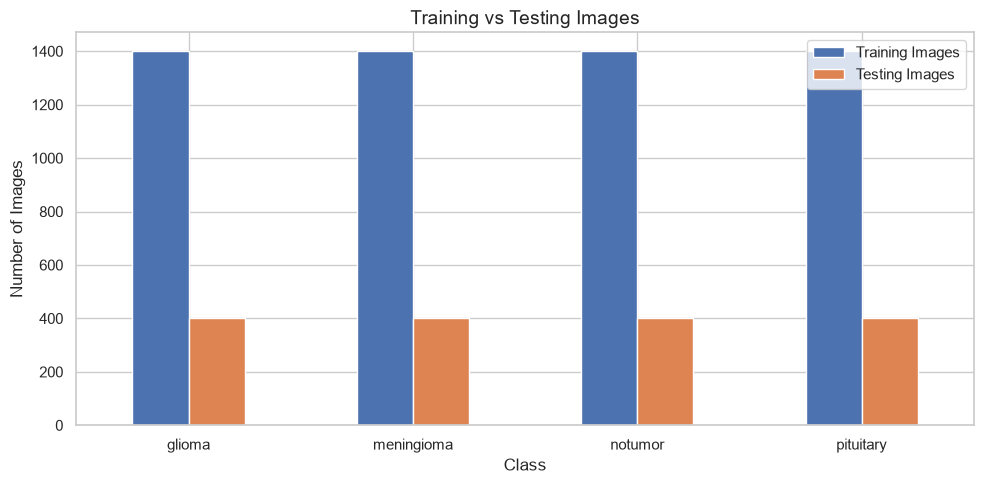

In [9]:
# ==========================================
# Train vs Test Distribution
# ==========================================

dataset_plot = dataset_df.set_index("Class")[
    ["Training Images", "Testing Images"]
]

dataset_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Training vs Testing Images")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Sample MRI Images


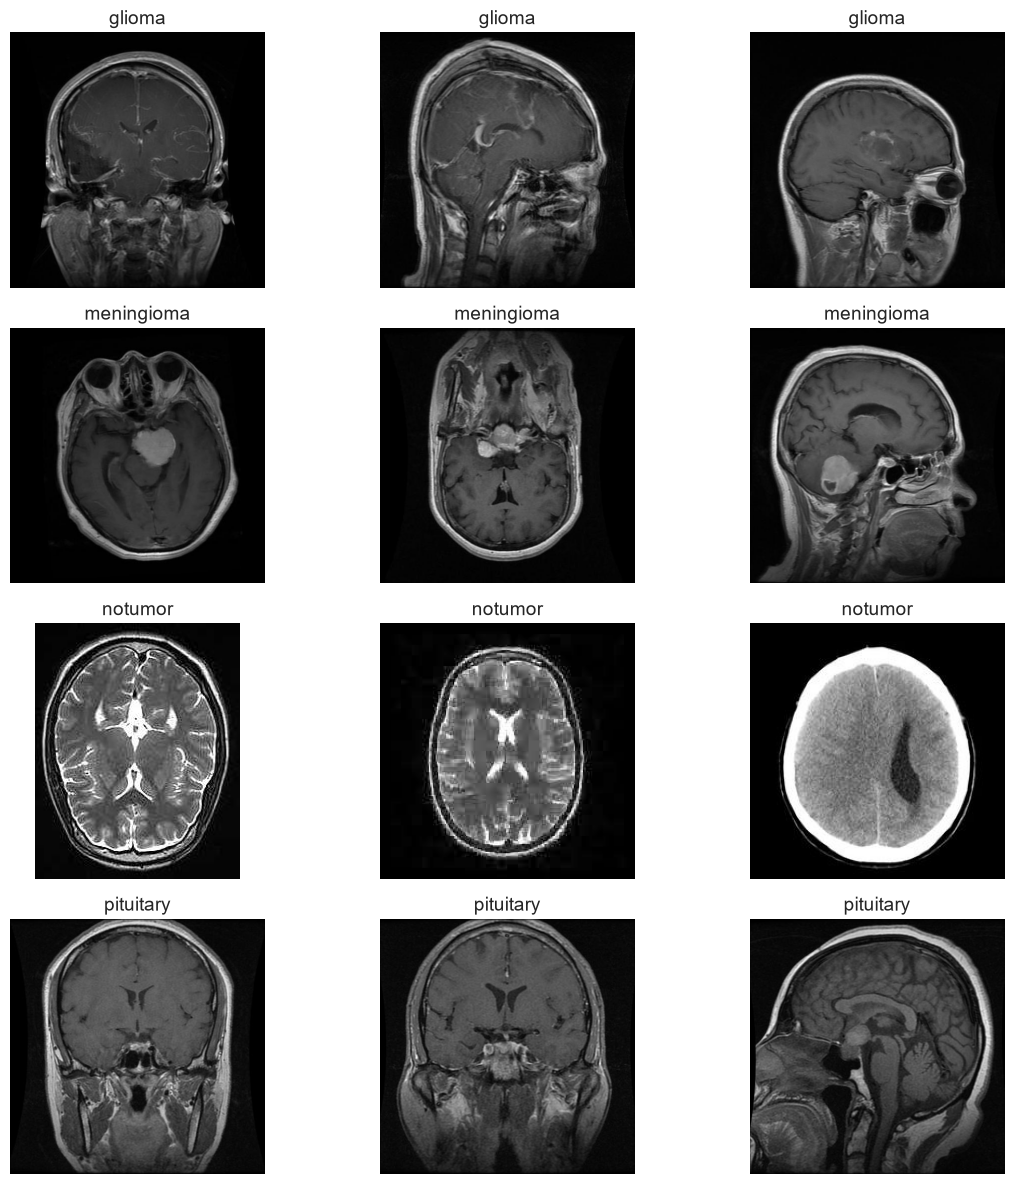

In [10]:
# ==========================================
# Display Sample MRI Images
# ==========================================

samples_per_class = 3

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    samples_per_class,
    figsize=(12, 12)
)

for row, class_name in enumerate(CLASS_NAMES):

    image_paths = list((TRAIN_DIR / class_name).glob("*"))[:samples_per_class]

    for col, image_path in enumerate(image_paths):

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")
        axes[row, col].set_title(class_name)

plt.tight_layout()
plt.show()

# Image Resolution Analysis

In [11]:
# ==========================================
# Analyze Image Resolution
# ==========================================

image_heights = []
image_widths = []

for class_name in CLASS_NAMES:

    image_paths = list((TRAIN_DIR / class_name).glob("*"))

    for image_path in image_paths:

        image = cv2.imread(str(image_path))

        if image is None:
            continue

        h, w = image.shape[:2]

        image_heights.append(h)
        image_widths.append(w)

resolution_df = pd.DataFrame({
    "Height": image_heights,
    "Width": image_widths
})

resolution_df.describe()

,Height,Width
count,5600.000000,5600.000000
mean,462.262857,458.513750
std,123.617483,129.619399
min,168.000000,150.000000
25%,512.000000,512.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1446.000000,1375.000000


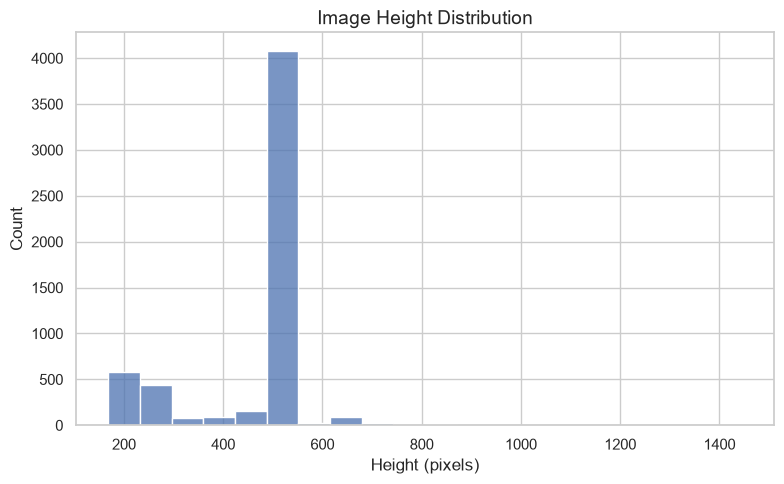

In [12]:
# ==========================================
# Image Height Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    resolution_df["Height"],
    bins=20
)

plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

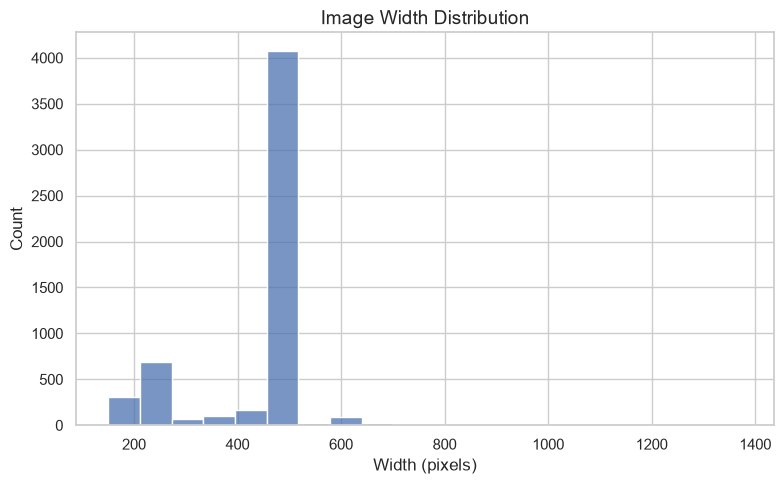

In [13]:
# ==========================================
# Image Width Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    resolution_df["Width"],
    bins=20
)

plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [14]:
# Image Quality Check

In [15]:
# ==========================================
# Detect Corrupted Images
# ==========================================

corrupted_images = []

for folder in [TRAIN_DIR, TEST_DIR]:

    for class_name in CLASS_NAMES:

        class_folder = folder / class_name

        for image_path in class_folder.glob("*"):

            image = cv2.imread(str(image_path))

            if image is None:

                corrupted_images.append(str(image_path))

print("="*60)

print(f"Corrupted Images Found : {len(corrupted_images)}")

print("="*60)

if len(corrupted_images) > 0:

    for img in corrupted_images:

        print(img)

Corrupted Images Found : 0


In [16]:
# ==========================================
# Verify Image Channels
# ==========================================

channel_summary = {}

for class_name in CLASS_NAMES:

    image_path = next((TRAIN_DIR / class_name).glob("*"))

    image = cv2.imread(str(image_path))

    channel_summary[class_name] = image.shape

channel_df = pd.DataFrame.from_dict(
    channel_summary,
    orient="index",
    columns=["Height","Width","Channels"]
)

channel_df

,Height,Width,Channels
glioma,512,512,3
meningioma,512,512,3
notumor,251,201,3
pituitary,512,512,3


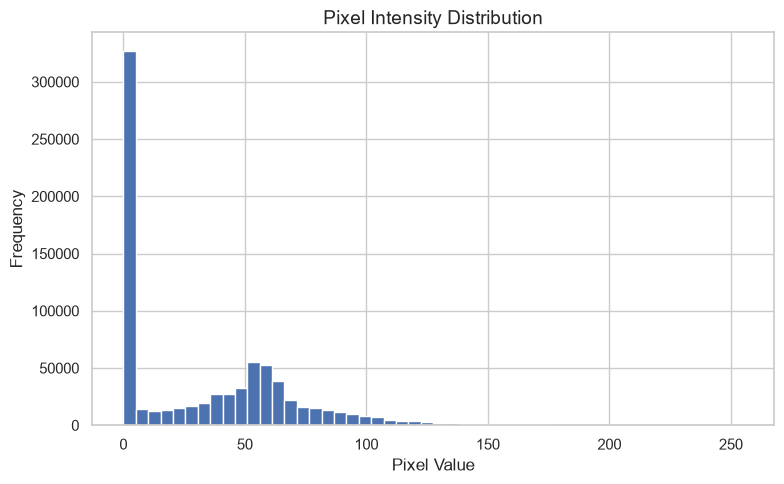

In [17]:
# ==========================================
# Pixel Intensity Distribution
# ==========================================

sample_image = cv2.imread(
    str(next((TRAIN_DIR / CLASS_NAMES[0]).glob("*")))
)

sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,5))

plt.hist(
    sample_image.ravel(),
    bins=50
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [18]:
# ==========================================
# Final EDA Summary
# ==========================================

print("="*65)

print("EDA COMPLETED SUCCESSFULLY")

print("="*65)

print(f"Classes              : {NUM_CLASSES}")

print(f"Training Images      : {total_train}")

print(f"Testing Images       : {total_test}")

print(f"Total Images         : {total_images}")

print(f"Image Size for Model : {IMAGE_SIZE}")

print(f"Batch Size           : {BATCH_SIZE}")

print(f"Corrupted Images     : {len(corrupted_images)}")

print("="*65)

EDA COMPLETED SUCCESSFULLY
Classes              : 4
Training Images      : 5600
Testing Images       : 1600
Total Images         : 7200
Image Size for Model : (224, 224)
Batch Size           : 32
Corrupted Images     : 0
